In [103]:
from typing import List
from typing_extensions import TypedDict

from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI
import sqlconfig

import pandas as pd

from langchain_experimental.agents import create_pandas_dataframe_agent



In [104]:
# Loading keys for OpenAI/LangSmith
from dotenv import load_dotenv
import os
load_dotenv()

True

In [105]:
from sqlalchemy import create_engine, MetaData
from langchain_community.utilities import SQLDatabase
uri = f"postgresql+psycopg2://{sqlconfig.DB_USER}:{sqlconfig.DB_PASSWORD}@{sqlconfig.DB_HOST}:{sqlconfig.DB_PORT}/{sqlconfig.DB_NAME}"
engine =  create_engine(uri)
metadata = MetaData()
metadata.reflect(bind=engine, schema='nba24_25_s')


db = SQLDatabase(engine=engine, metadata=metadata,schema='nba24_25_s', sample_rows_in_table_info= 10)
llm=ChatOllama(model="llama3.1:8b", temperature=0)
# llm=ChatOpenAI(model="gpt-4o", temperature=0) 

In [106]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

tools = toolkit.get_tools()



In [107]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# State passed from node to node
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]   # messages input/output
    table_names: str #Table names of database
    schema: str # Schema (Create statements of database)
    sql_query: str # Sql_query generated 
    last_sql_error: str # Most recent sql error 
    sql_error_bool:bool # Does most recent sql_query contain an error?
    not_related: str # Is the user query related to the db?
    sql_results:str # Results of sql_statement 
    python_df_code:str # Python code to create pandas df from sql_results
    python_df_object: pd.DataFrame # Dataframe object
    dataframe_init_error: str # Most recent Pandas dataframe init error
    plot_requested_bool: str # Does the user ask for a plot?
    plot_python_code:str # Python plot code
    last_plot_error:str # Last error in plot_python_code


In [108]:
from typing import Literal
from langchain_core.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

In [109]:
# Loading 4 main SQL tools
run_query_tool = tools[0]
run_query_node = ToolNode([run_query_tool], name="run_query")

get_schema_tool = tools[1]
get_schema_node = ToolNode([get_schema_tool], name="get_schema")

get_table_tool = tools[2]
get_table_node = ToolNode([get_table_tool], name="get_table")

query_check_tool = tools[3]
run_query_check_node = ToolNode([query_check_tool], name="run_query_check")

In [110]:
from langchain_core.messages import HumanMessage, SystemMessage


In [111]:
import re

# Initial node reads in table names and schema
def read_database_metadata(state: State):
    #Tool metadata
    tool_call = {
        "name": "sql_db_list_tables",
        "args": {},
        "id": "abc123",
        "type": "tool_call",
    }

    # Calling tool for table names of db
    tool_message = get_table_tool.invoke(tool_call)
    table_list_str = tool_message.content
    
    #Storing string of table names to state
    state['table_names']=table_list_str
    
    # Setting up args for schema metadata
    info_args = {"table_names": table_list_str}
    
    #schema metadata
    tool_call = {
        "name":"sql_db_schema",
        "args":info_args,
        "id":"morpeko",
        "type":"tool_call"
    }

    #Calling tool for schema of tables
    schema_message=get_schema_tool.invoke(tool_call)

    #Extracting all CREATE statements
    create_statements = re.findall(r"CREATE TABLE.*?\/", schema_message.content, re.DOTALL)

    #Storing all CREATE statements to state for next node
    state['schema']="\n".join(create_statements)
    return state

# Checks if prompt is related to db and generates SQL query
def init_sql_generator(state: State):

    # Main prompt for agent
    prompt=f""""
        You are an expert at determining if the query from the user is related to a query on the database on the NBA provided to you. 
        You have the following tables available to you: {state['table_names']}
        The data manipulation language to create the table is as follows: {state['schema']}
        Determine if the input question from the user "{state['messages'][0].content}" is related to a query on the database provided to you. 
        If the input query is related to the database based off the schema you have available to you, wrap the SQL statement you create in a response like so: 

        ``` 
        SELECT colname from tablename;
        ```        
        If the input query is not related, do not write any SQL statements.
        Always write a SQL statement if the input question is related to the database in any way. 
        The input query may be limited so make sure to understand if you need to do any joins before being able to do SQL SELECT statements to satisfy the user's query. 
        Never SELECT id as the only thing to GROUP BY as id's are not interesting.
    """

    messages=[
        # System message for behavior of agent
        SystemMessage(content=f""""You are an agent designed to interact with a SQL database. 
                      Never return DML statements (INSERT, UPDATE, DELETE, DROP etc.).
                      Do not make any stretches in your imagination.
                      """),
        HumanMessage(content=f"{prompt}")
    ]

    # Calling agent
    response=llm.invoke(messages)
    content=response.content

    # Extracting SQL statement from response
    select_statements = re.search(r"SELECT.*?;", content, re.DOTALL)

    # Setting sql_query for next nodes
    if select_statements:
        sql_query=select_statements.group(0)
        state['sql_query']=sql_query  
    else:
        state['sql_query']=""

    return state

# Checks if sql_query is empty. # If empty, prints END signaling graph to end 
def not_related_to_db(state: State):

    prompt=f"""The provided string is: x = {state['sql_query']}. If the provided string x is empty print "END". If not print "SQL"."""

    messages=[
        SystemMessage(content=f""""You are an agent designed to print one word. Do not print anything else. Do not write any function."""),
        HumanMessage(content=f"{prompt}")
    ]

    response=llm.invoke(messages)
    state['not_related']=response.content

    return state

# Ends graph if previous node resulted in END statement (User query not related to the DB)
def end_or_sql_query(state: State):
    if state['not_related']=='END':
        return True
    else: 
        return False

# Checks if SQL query generated in sql_query is valid
def sql_query_checker(state: State):
    # Invoking tool for checking if sql_query is valid
    response=query_check_tool.invoke({"query": state['sql_query']})

    content=response
    # Extracting only the SQL SELECT statement
    select_statements = re.search(r"SELECT.*?;", content, re.DOTALL)

    # Setting sql_query for next nodes
    if select_statements:
        sql_query=select_statements.group(0)
        state['sql_query']=sql_query  
    else:
        state['sql_query']=""

    return state


# Executes SQL Query
def sql_query_executor(state: State):

    # Executes SQL Query using tool
    response=run_query_tool.invoke({"query": state['sql_query']})

    #Extracts error from tool
    error = re.search(r"Error:", response, re.DOTALL)

    
    if error:
        # Passes error to sql_query_fixer allowing for next agent to fix query based off error
        state['last_sql_error']=response
        state['sql_error_bool']=True
    else:
        state['sql_results']=response
        state['sql_error_bool']=False
  
    return state

# Ends sql fixing loop 
def is_sql_query_error(state: State):
    if state['sql_error_bool']==False:
        return False
    else:
        return True
    
# Fixes SQL statement and loops back to sql_query_executor
def sql_query_fixer(state: State):
    
    # Prompt for fixing sql query
    prompt=f"""This sql query failed: {state['sql_query']}.  
               The error for the attempted sql query attempted is {state['last_sql_error']}.   
               Remember that the available tables are {state['table_names']}
               Remember that the schema of the database is as follows {state['schema']}.       
    """


    messages=[
        # System message for sql fixer agent
        SystemMessage(content=f""""You are an expert at SQL. You are tasked with fixing errors in SQL queries.
                       Only return the corrected SQL select statement.
                       Common errors is not joining tables correctly and trying to select from columns that are not in the table.
                       Other common errors is attempting to SELECT columns that are not aggregated or a part of the group by clause.
                       Other common errors is not using window functions and not using Common Table Expressions when it is more efficient.
                       Do not explain your thinking.                 
                       Do not print anything else."""),
        HumanMessage(content=f"{prompt}")
    ]

    # Invoking sql fixer agent
    response=llm.invoke(messages)
    content=response.content

    # Extracting SELECT statement from response
    select_statements = re.search(r"SELECT.*?;", content, re.DOTALL)

    # Storing SELECT statement back to sql_query for execution
    if select_statements:
        sql_query=select_statements.group(0)
        state['sql_query']=sql_query    

    return state

# Generates Python code for creating Pandas dataframe
def df_code_creator(state: State):
    prompt=f"""This is a sql query {state['sql_query']} with the following results stored in a variable called y {state['sql_results']}.  
               Print the code to create the Pandas dataframe.
    """

    messages=[
        SystemMessage(content=f""""You are an expert at understanding Pandas and SQL. 
                      You are tasked with creating Python code to create a Pandas dataframe given a SQL SELECT statement 
                      and the results of the SQL query as a list with tuples representing each row of the dataframe.
                      Make sure to give the columns of the pandas dataframe appropriate names.
                      Only return the Python code one liner to create the Pandas dataframe.
                      Do not explain your thinking. Do not wrap the Python code in ```Python ```                 
                      """),
        HumanMessage(content=f"{prompt}")
    ]
    
    # Invoking agent to create Python Pandas code and storing into state for next node
    response=llm.invoke(messages)
    content=response.content
    state['python_df_code']=content
    return state

# Creating dataframe object in Python and determining if a plot is needed.
def dataframe_init(state:State):
    try:
        # Executing list of sql_results as a variable for Pandas code
        y=eval(state['sql_results'])
    
        # Executing Python code to create Pandas dataframe and storing Pandas dataframe back to state 
        df=eval(state['python_df_code'])
        state['python_df_object']=df
 
        #No dataframe initialization error
        state['dataframe_init_error']=None
        
        return state
    # Dataframe initilization error for creation of Pandas Dataframe.     
    except Exception as E:
        state['dataframe_init_error']=E
        return state
    
# Node for checking if plot is requested
def plot_requested(state: State):
     # Prompt for determining if a plot needs to be made
    prompt=f"""This is the query that the user gave to you {state['messages'][0].content}.  
            If the prompt is related to creating a visualization of any kind print a statement about the type of plot the user wants.  
            If the prompt is not related to creating a plot print "END".
    """

    messages=[
        SystemMessage(content=f""""You are an agent that is an expert at understanding if the end user wants a dataframe or if they want a plot.
                    Do not explain your thinking. Do not print anything else.                 
                    """),
        HumanMessage(content=f"{prompt}")
    ]
        
    response=llm.invoke(messages)
    content=response.content
    
    # Storing if a plot is requested to state for next nodes
    state['plot_requested_bool']=content
    return state

# Returns True if there is an dataframe initialization error
def is_dataframe_init_error(state: State):
    if state['dataframe_init_error']:
        return True
    else:
        return False
    
def dataframe_init_fixer(state: State):
    prompt=f"""  
            This is the previous python code that was used to initialize a dataframe {state['python_df_code']}.
            It resulted in the following error {state['dataframe_init_error']}. 
            Fix the python code based off of the error. 
            Do not wrap the python code in ```python ```. 
    """

    messages=[
        SystemMessage(content=f""""You are an agent that is an expert at python. The user has python code related to a prompt that results in an error. 
                    Return the corrected correct python code. Assume that the user has already defined the variable y that contains the list of tuples from a SQL query. 
                    So the contents of the dataframe to not need to be redefined only the pandas statement to create the dataframe using the list of tuples stored in y.
                    Do not explain your thinking. Do not print anything else.                 
                    """),
        HumanMessage(content=f"{prompt}")
    ]

    response=llm.invoke(messages)
    state['python_df_code']=response.content

    return state

# Ending condition if plot is not needed
def plot_or_end(state: State):
    if state['plot_requested_bool']=="END":
        return False
    else:
        return True
    


In [ ]:

# Node for generating plots    
def plot_code_generator(state:State):
    # Prompt for creating Python plot code
    prompt=f"""This is the query that the user gave to you {state['messages'][0].content}.  
               The user wants a visualization on the following dataframe stored in df. {state['python_df_object']}
               Use the appropriate tool to create the visualizations with proper naming of columns as you see appropriate.
               Return the Python code to create the plot that the user wants. 
    """

    messages=[
        SystemMessage(content=f""""You are an agent that is an expert at creating Python code for plots. 
                      Do not explain your thinking. Provide the necessary imports for plotting as well as the python code to create the plot.
                      Do not define the dataframe in your code.
                      Do not wrap the code in ```Python ```.            
                     """),
        HumanMessage(content=f"{prompt}")
    ]

    response=llm.invoke(messages)

    # Storing Python plot code for execution in other nodes
    state['plot_python_code']=response.content

    return state

# Node for executing Python plot code
def plot_code_executor(state:State):
    try:
        #Storing the Pandas dataframe in variable df
        df=state['python_df_object']
        
        #Executing the Python plot code on df
        exec(state['plot_python_code'])

        #Setting last_plot_error to if no errors occured
        state['last_plot_error']=None

    except Exception as e:
        # Storing Python plot error to state for next nodes
        state['last_plot_error']=e    
    return state

# Condition to end if there is no plot error
def plot_error(state: State):
    if state['last_plot_error']:
        return True
    else:
        return False

# Node for fixing plot errors
def plot_error_fixer(state:State):
    # Prompts for plot code fixer agent
    prompt=f"""This is the query that the user gave to you {state['messages'][0].content}.  
               This is the dataframe that the user wanted to plot {state['python_df_object']}
               This is the previous Python plot code that resulted in an error {state['plot_python_code']}. 
               This is the error of the Python plot code {state['last_plot_error']}
               Fix the Python code to correctly handle the error.
               Return the Python code to create the plot that the user wants with the error fixed. 
    """

    messages=[
        SystemMessage(content=f""""You are an Python agent that is an expert at plotting using matplotlib. 
                      Fix any errors that were provided to you. 
                      Do not explain your thinking. Only provide the necessary imports for plotting as well as the python code to create the plot. Do not wrap the code in ```Python ```.    
                     """),
        HumanMessage(content=f"{prompt}")
    ]

    # Returning python plot code back    
    response=llm.invoke(messages)
    state['plot_python_code']=response.content
   
    return state

def printer(state: State):
    #Storing the results of the SQL query as a Pandas dataframe to end user. Might want to do this at the end of the graph instead.
    if state['not_related']=='END':
        final_results=AIMessage(content=f"""Your query is not related to the database.""")
    else:
    # elif state['plot_requested_bool']=='END':
        final_results=AIMessage(content=f"""This is the resulting SQL query: \n\n {state['sql_query']} \n \n This is the resulting dataframe from the SQL query: \n\n {state['python_df_object'].to_markdown(index=False)}""")
    
    #else 

    state['messages']=[final_results]
    
    
    return state



In [113]:
from langgraph.graph import START, StateGraph,END
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

In [114]:
builder = StateGraph(State)

# adding all the nodes.
builder.add_node("read_database_metadata", read_database_metadata)
builder.add_node("init_sql_generator",init_sql_generator)
builder.add_node("not_related_to_db",not_related_to_db)
builder.add_node("sql_query_checker",sql_query_checker)
builder.add_node("sql_query_executor",sql_query_executor)
builder.add_node("sql_query_fixer",sql_query_fixer)
builder.add_node("df_code_creator",df_code_creator)
builder.add_node("dataframe_init",dataframe_init)
builder.add_node("dataframe_init_fixer",dataframe_init_fixer)
builder.add_node("plot_code_generator",plot_code_generator)
builder.add_node("plot_code_executor",plot_code_executor)
builder.add_node("plot_error_fixer",plot_error_fixer)
builder.add_node("plot_requested",plot_requested)
builder.add_node("printer",printer)

# Adding all edges
builder.add_edge(START, "read_database_metadata")
builder.add_edge("read_database_metadata","init_sql_generator")
builder.add_edge("init_sql_generator", "not_related_to_db")

builder.add_conditional_edges("not_related_to_db",end_or_sql_query,{
    True: "printer",
    False: "sql_query_checker"
})

builder.add_edge("sql_query_checker","sql_query_executor")

builder.add_conditional_edges("sql_query_executor",is_sql_query_error,{
    False: "df_code_creator",
    True: "sql_query_fixer"
})

builder.add_edge("sql_query_fixer","sql_query_checker")
builder.add_edge("df_code_creator","dataframe_init")


builder.add_conditional_edges("dataframe_init",is_dataframe_init_error,{
    True: "dataframe_init_fixer",
    False: "plot_requested"
})

builder.add_conditional_edges("plot_requested",plot_or_end,{
    False: "printer",
    True: "plot_code_generator"
})

builder.add_edge("dataframe_init_fixer","dataframe_init")

builder.add_edge("plot_code_generator", "plot_code_executor")

builder.add_conditional_edges("plot_code_executor",plot_error,{
    True: "plot_error_fixer",
    False: "printer"
})

builder.add_edge("plot_error_fixer","plot_code_executor")

builder.add_edge("printer",END)

react_graph = builder.compile()





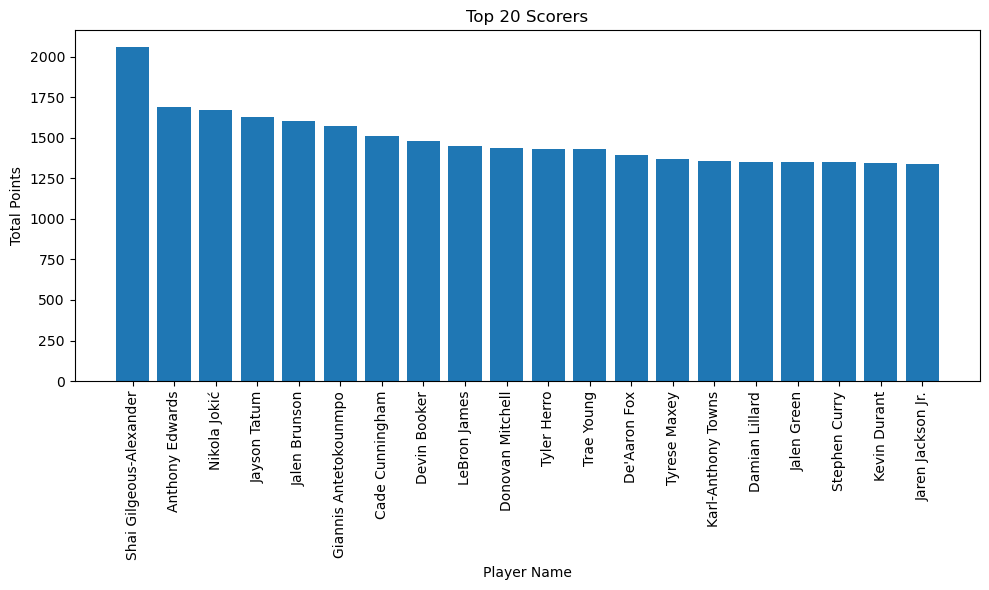

In [115]:
messages = [HumanMessage(content="Visualize the point of the top 20 scorers with the player names on the x-axis and their points all summed up.")]
messages = react_graph.invoke({"messages": messages})

In [116]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Visualize the point of the top 20 scorers with the player names on the x-axis and their points all summed up.
================================== Ai Message ==================================

This is the resulting SQL query: 

 SELECT 
    ap.player_first_name, 
    ap.player_last_name, 
    SUM(bs.pts) AS total_points
FROM 
    boxscores bs
JOIN 
    active_nba_players ap ON bs.player_id = ap.player_id
GROUP BY 
    ap.player_first_name, 
    ap.player_last_name
ORDER BY 
    total_points DESC
LIMIT 20; 
 
 This is the resulting dataframe from the SQL query: 
 | player_first_name   | player_last_name   |   total_points | player_name             |
|:--------------------|:-------------------|---------------:|:------------------------|
| Shai                | Gilgeous-Alexander |           2059 | Shai Gilgeous-Alexander |
| Anthony             | Edwards            |           1688 | Anthony Edwards         